In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
plt.rcParams['font.family'] = 'Arial'
from scipy.stats import pearsonr
from matplotlib.ticker import MaxNLocator
from matplotlib.colors import LogNorm, LinearSegmentedColormap

In [2]:
gridsize=70

names = {
    'kodama-gwas': 'kodama-gwas',
    'kodama-gwas-rv': 'kodama-gwas-rv',
    'kodama-gwas-rac': 'kodama-gwas-rv',
    'plink-qtr': 'PLINK 2.0 qt-residualize',
    'plink': 'PLINK 2.0',
}

colors = {
    'kodama-gwas': '#56C1FF', # blue
    'kodama-gwas-rv': '#A8C256', # green
    'kodama-gwas-rac': '#A8C256', # green
    'plink': '#E9B824', # yellow,
    'plink-qtr': '#e67487', # pink
}

# Create custom colormaps with bright saturated colors
def make_cmap(light_color, bright_color, name='custom'):
    """Create a colormap from light tint to bright saturated color."""
    return LinearSegmentedColormap.from_list(name, ['#ffffff', light_color, bright_color])                                    
                                                                                                                                   
cmaps = {                                                                                                                        
    'kodama-gwas': make_cmap('#5ec4ff', '#0066cc', 'blue_cmap'),                                                                 
    'kodama-gwas-rv': make_cmap('#a8c256', '#4a8c00', 'green_cmap'),                                                             
    'kodama-gwas-rac': make_cmap('#a8c256', '#4a8c00', 'green_cmap'),                                                            
    'plink': make_cmap('#f0c020', '#cc8800', 'yellow_cmap'),                                                                     
    'plink-qtr': make_cmap('#e67487', '#c41040', 'pink_cmap'),                                                                   
}

stat_map = {
    'z': 'z-score',
    'beta': 'beta',
    'se': 'SE'   
}

In [3]:
df = pd.read_csv('../figure4/4bd/data/kodama-gwas-rac_plink_all_bilirubin_gwas_comparison_chr11.tsv', sep='\t')
df

,ID,AF,A1FREQ,kodama-gwas-rac_beta,kodama-gwas-rac_se,kodama-gwas-rac_z,plink_beta,plink_se,plink_z,plink-qtr_beta,plink-qtr_se,plink-qtr_z
0,11:103091:G:A,0.000006,0.000005,0.228950,0.680111,0.336636,0.228905,0.680054,0.336598,0.228709,0.679674,0.336498
1,11:103131:G:A,0.000009,0.000008,0.219289,0.447826,0.489675,0.203257,0.430738,0.471881,0.202485,0.429863,0.471045
2,11:103150:G:A,0.000034,0.000035,0.356490,0.254906,1.398516,0.338785,0.248474,1.363463,0.338085,0.248185,1.362230
3,11:103160:TTAAAA:T,0.000102,0.000118,-0.012867,0.141793,-0.090747,-0.012539,0.140294,-0.089374,-0.012528,0.140215,-0.089348
4,11:103168:A:G,0.000006,0.000005,0.705038,0.679902,1.036969,0.704842,0.679833,1.036787,0.704690,0.679672,1.036809
...,...,...,...,...,...,...,...,...,...,...,...,...
29535681,11:135076570:GT:G,0.000918,0.000960,0.031460,0.052545,0.598730,0.032017,0.052972,0.604423,0.032007,0.052956,0.604399
29535682,11:135076576:G:C,0.000194,0.000190,0.163901,0.111537,1.469483,0.162477,0.111043,1.463190,0.162412,0.111007,1.463079
29535683,11:135076578:T:C,0.000176,0.000193,0.019013,0.119330,0.159330,0.020395,0.123291,0.165425,0.020334,0.123089,0.165196
29535684,11:135076584:T:A,0.000545,0.000558,-0.046138,0.068064,-0.677865,-0.045391,0.067514,-0.672324,-0.045377,0.067495,-0.672307


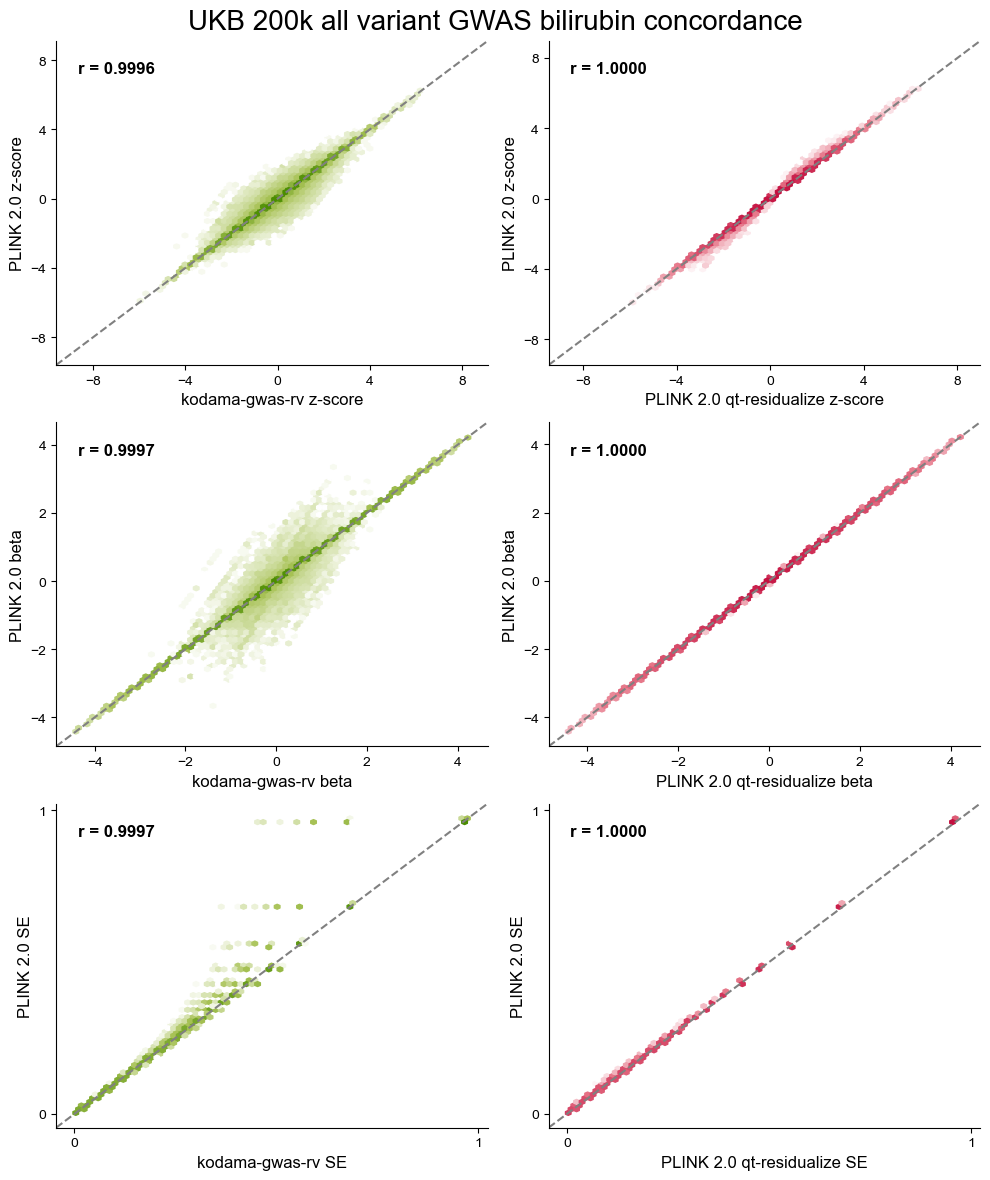

In [4]:
stats = ['z', 'beta', 'se']
methods = ['kodama-gwas-rac', 'plink-qtr']

fig, axes = plt.subplots(len(stats), len(methods), figsize=(5 * len(methods), 4 * len(stats)))

for i, stat in enumerate(stats):
    for j, method in enumerate(methods):
        ax = axes[i, j] if len(stats) > 1 else axes[j]

        x = df[f'{method}_{stat}']
        y = df[f'plink_{stat}']

        # Hexbin density plot (no colorbar)
        ax.hexbin(x, y, gridsize=gridsize, cmap=cmaps[method], mincnt=1, norm=LogNorm())
        ax.set_xlabel(f"{names[method]} {stat_map[stat]}", fontsize=12)
        ax.set_ylabel(f"PLINK 2.0 {stat_map[stat]}", fontsize=12)

        # Equal limits and diagonal
        lims = [min(ax.get_xlim()[0], ax.get_ylim()[0]),
                max(ax.get_xlim()[1], ax.get_ylim()[1])]
        ax.plot(lims, lims, '--', color='grey')
        ax.set_xlim(lims)
        ax.set_ylim(lims)

        # Reduce tick count
        ax.xaxis.set_major_locator(MaxNLocator(integer=True, nbins=5))
        ax.yaxis.set_major_locator(MaxNLocator(integer=True, nbins=5))

        # Compute and display correlation
        r, _ = pearsonr(x, y)
        ax.spines['right'].set_visible(False)
        ax.spines['top'].set_visible(False)
        ax.text(0.05, 0.9, f"r = {r:.4f}", transform=ax.transAxes,
                fontsize=12, fontweight='bold', color='black',
                bbox=dict(facecolor='white', alpha=0.7, edgecolor='none'))



fig.suptitle("UKB 200k all variant GWAS bilirubin concordance", fontsize=20)
plt.tight_layout(rect=[0, 0, 1, 1])
plt.show()

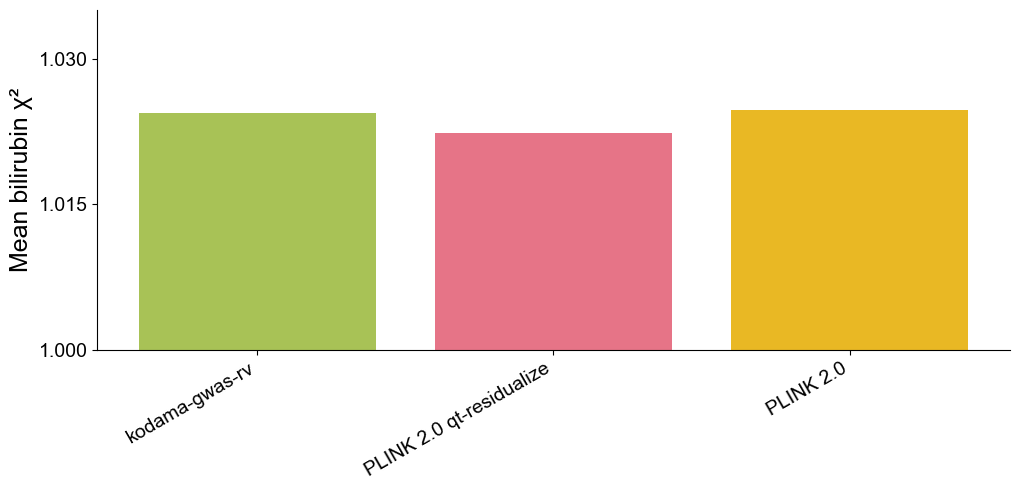

In [5]:
plt.rcParams['font.family'] = 'Arial'

methods = ['kodama-gwas-rac', 'plink-qtr', 'plink']

mean_chi2 = [np.mean(df[f'{method}_z']**2) for method in methods]

labels = [names[m] for m in methods]
bar_colors = [colors[m] for m in methods]

# --- Plot ---
ymin = 1.00
ymax = 1.03
plt.figure(figsize=(10, 5))
plt.bar(labels, mean_chi2, color=bar_colors)
plt.ylabel("Mean bilirubin χ²", fontsize=18)
plt.xticks(rotation=30, ha='right', fontsize=14)
plt.tight_layout()
plt.ylim(ymin, ymax + 0.005)
plt.yticks(np.linspace(ymin, ymax, 3), fontsize=14)
plt.gca().spines['right'].set_visible(False)
plt.gca().spines['top'].set_visible(False)
plt.show()

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

plt.rcParams['font.family'] = 'Arial'

In [7]:
df = pd.read_csv('../figure4/4bd/data/kodama-gwas_plink_correlation.tsv', sep='\t')
df

,trait,missingness,n_variants,kodama-gwas-rv_chr11_beta,kodama-gwas-rv_chr11_se,kodama-gwas-rv_chr11_z,kodama-gwas_chr1-22_beta,kodama-gwas_chr1-22_se,kodama-gwas_chr1-22_z
0,p30240,0.046236,8871279,0.999183,0.998672,0.999371,0.999361,0.999950,0.999538
1,p100012,0.553116,8843913,0.999108,0.997803,0.998267,0.998449,0.999249,0.999303
2,p23407,0.434413,8856746,0.998727,0.997682,0.998302,0.998819,0.999732,0.999300
3,p23465,0.434498,8856744,0.999156,0.998080,0.998303,0.999133,0.999732,0.999387
4,p23478,0.447744,8855960,0.999178,0.997982,0.998310,0.999164,0.999715,0.999502
...,...,...,...,...,...,...,...,...,...
84,p23099,0.016472,8871725,0.999389,0.999107,0.999546,0.999518,0.999969,0.999645
85,p26052,0.553161,8843907,0.999113,0.997705,0.998267,0.998557,0.999247,0.999377
86,p23098,0.015982,8871729,0.999509,0.999145,0.999547,0.999601,0.999969,0.999705
87,p23434,0.434859,8856694,0.998724,0.997483,0.998302,0.999100,0.999732,0.999427


In [8]:
names = {
    'kodama-gwas': 'kodama-gwas',
    'kodama-gwas-rv': 'kodama-gwas-rv',
    'plink-qtr': 'PLINK 2.0 qt-residualize',
    'plink': 'PLINK 2.0',
}

colors = {
    'kodama-gwas': '#56C1FF', # blue
    'kodama-gwas-rv': '#A8C256', # green
    'plink': '#E9B824', # yellow,
    'plink-qtr': '#e67487', # pink
}

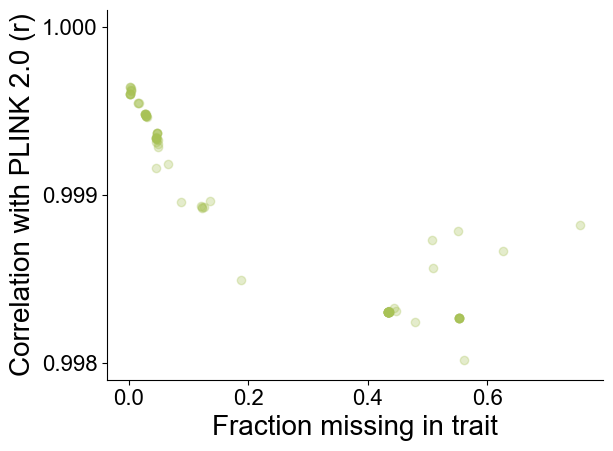

In [9]:
config = 'kodama-gwas-rv_chr11'
model = config.split('_')[0]

ymin = 0.998
ymax = 1

fig, ax = plt.subplots()

ax.scatter(
    df.missingness,
    df[f'{config}_z'],
    color=colors[model],
    alpha=0.3
)

ax.set_xlabel('Fraction missing in trait', fontsize=20)
ax.set_ylabel('Correlation with PLINK 2.0 (r)', fontsize=20)

# Y-range
ax.set_ylim(ymin - 0.0001, ymax + 0.0001)
ax.set_yticks(np.linspace(ymin, ymax, 3))

# Tick sizes
ax.tick_params(axis='y', labelsize=16)
ax.tick_params(axis='x', labelsize=16)

# Style
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)

plt.show()